# U‑Net–Based Cell Segmentation with Morphological Analysis






This notebook presents a complete deep‑learning workflow for biomedical cell segmentation using a U‑Net architecture. The pipeline integrates data preparation, preprocessing, augmentation, model training, and quantitative evaluation to provide a clear and reproducible approach to semantic segmentation in microscopy imaging.

Beyond pixel‑wise segmentation, the notebook performs instance‑level morphological analysis by applying connected‑component labelling to the predicted masks and extracting geometric features such as area, perimeter, eccentricity, and circularity. This demonstrates how semantic segmentation outputs can support downstream quantitative tasks, including cell counting, shape analysis, and population‑level comparisons with ground‑truth annotations.

# Dataset and Data Aquisition

The experiments in this notebook use the BCCD dataset, published on Kaggle by Jeet B. Lahiri. The dataset contains microscopy images of various cells together with corresponding pixel‑level annotations for semantic segmentation. The images and masks were downloaded directly from the Kaggle dataset page and are not included in this repository.

The dataset is distributed under the MIT Licence. Users should refer to the original Kaggle page for full licence terms and authorship information.

In [1]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Extract the dataset ZIP file directly from Google Drive into the Colab environment.
import zipfile

zip_path = "/content/drive/MyDrive/BCCD_Dataset_With_Mask.zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("bccd")

print("Dataset extracted to: bccd/")


Dataset extracted to: bccd/


# Data Preprocessing

This section prepares the dataset for training by standardising image dimensions, normalising pixel intensities, and constructing reproducible training, validation, and test splits. All images and masks are resized to 256×256 to provide a consistent input resolution for the U‑Net architecture. After preprocessing, a visual inspection is performed to verify that each image is correctly paired with its corresponding mask.

In [3]:
# Core libraries for file handling, image processing, and numerial operations.
import os
import cv2
import numpy as np
import pandas as pd

# Plotting and visualisation
import matplotlib.pyplot as plt

# Data Augmentation
import albumentations as A

# Deep Learning framework
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

# Dataset splitting and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score, precision_score, recall_score

from skimage.measure import label, regionprops


In [4]:
# Paths to the extracted dataset folders
TRAIN_IMG_DIR = "/content/bccd/BCCD Dataset with mask/train/original"
TRAIN_MASK_DIR = "/content/bccd/BCCD Dataset with mask/train/mask"

TEST_IMG_DIR = "/content/bccd/BCCD Dataset with mask/test/original"
TEST_MASK_DIR = "/content/bccd/BCCD Dataset with mask/test/mask"

# Target image size for U-Net and classical segmentation comparison.
IMG_SIZE = 256

**Resize and Reload Functions :**

In [5]:
# Load an image from disk, convert to RGB, resize to 256x256, and normalise to [0,1].
def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype("float32") / 255.0

# Load a segmentation mask, convert to grayscale, resize, and binarise.
# Binarisation ensures the mask is 0 (background) or 1 (cell).
def load_mask(path):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = (mask > 0).astype("float32") # convert to binary mask
    return np.expand_dims(mask, axis=-1) # add channel dimension


**Collect all Images and Masks :**

In [6]:
# Collect file paths from train and test folders
train_images = sorted([os.path.join(TRAIN_IMG_DIR, f) for f in os.listdir(TRAIN_IMG_DIR)])
train_masks  = sorted([os.path.join(TRAIN_MASK_DIR, f) for f in os.listdir(TRAIN_MASK_DIR)])

test_images = sorted([os.path.join(TEST_IMG_DIR, f) for f in os.listdir(TEST_IMG_DIR)])
test_masks  = sorted([os.path.join(TEST_MASK_DIR, f) for f in os.listdir(TEST_MASK_DIR)])

# Combine them into one dataset
all_images = train_images + test_images
all_masks  = train_masks + test_masks

# Load into arrays
X = np.array([load_image(f) for f in all_images])
y = np.array([load_mask(f) for f in all_masks])

print("Loaded images:", X.shape)
print("Loaded masks:", y.shape)


Loaded images: (1328, 256, 256, 3)
Loaded masks: (1328, 256, 256, 1)


**Train / Validation / Test Split :**

In [7]:
# First split: train vs temp (val & test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42
)


# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Train set: (1062, 256, 256, 3)
Validation set: (133, 256, 256, 3)
Test set: (133, 256, 256, 3)


**Visually Check Image and Mask pairs are consistent :**

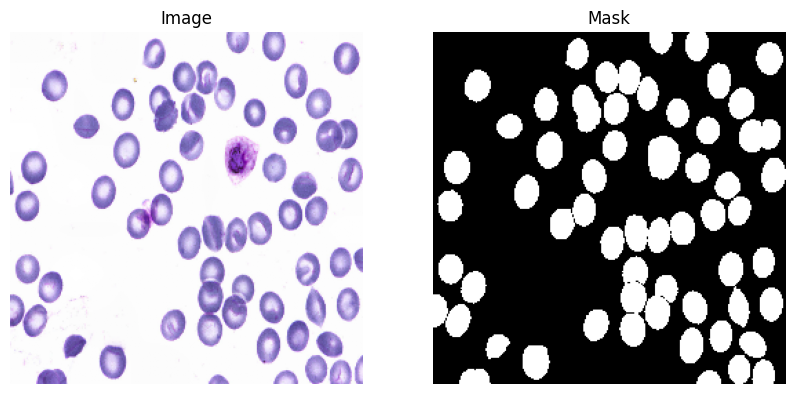

In [8]:
i = 0  # any index from 0 to len(X)-1

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(X[i])
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(y[i].squeeze(), cmap="gray")
plt.axis("off")

plt.show()


# Data Augmentation (Training‑Only) :

Augmentation introduces controlled variability into the training data to improve the model’s ability to generalise to unseen samples. The transformations applied include rotations, flips, affine adjustments, and intensity variations. Augmentation is applied exclusively to the training set; the validation and test sets remain unchanged to ensure unbiased evaluation.

In [9]:
# Data augmentation using Albumentations.
# These transformations simulate realistic variations in microscopy images
# while preserving the biological structure of the cells.

augment = A.Compose([
    A.HorizontalFlip(p=0.5),          # flip images horizontally
    A.VerticalFlip(p=0.5),            # flip images vertically
    A.RandomRotate90(p=0.5),          # rotate by 90-degree increments

    # Replacement for ShiftScaleRotate
    A.Affine(
        scale=(0.9, 1.1),             # zoom in/out +/-10%
        translate_percent=(0.05, 0.05),  # shift up to 5%
        rotate=(-15, 15),             # rotate +/- 15 degrees
        p=0.5
    ),                                # small shifts, zooms, and rotations

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    ),                                      # simulate lighting variation
])


In [10]:
# Apply augmentation to an image-mask pair training batches
# Albumentations ensures that the same transformation is applied to both.

def augment_pair(image, mask):
    augmented = augment(image=image, mask=mask)
    return augmented["image"], augmented["mask"]


**Check the Augumentation are biologically reasonable :**

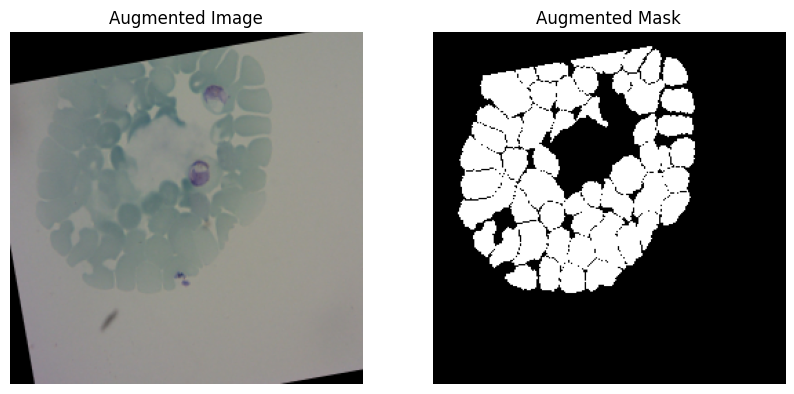

In [11]:
# Visualise a few augmented samples to verify correctness.

idx = 0  # choose any index from the training set
sample_img = X_train[idx]
sample_mask = y_train[idx]

aug_img, aug_mask = augment_pair(sample_img, sample_mask)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Augmented Image")
plt.imshow(aug_img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Augmented Mask")
plt.imshow(aug_mask.squeeze(), cmap="gray")
plt.axis("off")

plt.show()


# U-Net Model Architecture

U‑Net is a convolutional encoder–decoder architecture with skip connections that transfer spatial information from the contracting path to the expanding path. This design enables precise localisation while maintaining contextual understanding, making it well suited for pixel‑wise segmentation tasks in biomedical imaging. The model used in this notebook follows the standard U‑Net configuration, consisting of successive downsampling and upsampling blocks with feature concatenation at each resolution level.

In [12]:
# U-Net architecture for biomedical image segmentation.
# This implementation follows the standard encoder-decoder structure with skip connections.

def conv_block(x, filters):
    # Two convolutional layers with ReLU activation and same padding.
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x

def encoder_block(x, filters):
    # Convolution block followed by max pooling for downsampling.
    f = conv_block(x, filters)
    p = layers.MaxPooling2D((2, 2))(f)
    return f, p

def decoder_block(x, skip, filters):
    # Upsampling followed by concatenation with skip connection.
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # Output layer: 1 channel mask with sigmoid activation.
    outputs = layers.Conv2D(1, 1, padding="same", activation="sigmoid")(d4)

    model = models.Model(inputs, outputs)
    return model

unet = build_unet()
unet.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

# Training Procedure

This section defines the loss function, optimisation strategy, and training procedure used for the U‑Net model. The network is trained using a combination of Binary Cross‑Entropy and Dice loss, which balances pixel‑wise accuracy with overlap‑based optimisation. The model is optimised with Adam and trained for 30 epochs using the predefined training, validation, and test splits.

**Dice Coefficient and Dice Loss Functions :**

In [13]:
# Dice coefficient measures overlap between predicted and true masks.
# Dice loss = 1 - Dice coefficient, encouraging higher overlap.

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    # Flatten tensors to compute overlap.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f)

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)


**Combined BCE and Dice Loss :**

In [14]:
# Combined loss: Binary Cross-Entropy + Dice Loss.
# This aims to balance pixel-level accuracy with region-level overlap.

bce = tf.keras.losses.BinaryCrossentropy()

def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)


**Compile the U-Net Model :**

In [15]:
# Compile the U-Net with Adam optimiser and the combined loss.
# Dice coefficient is added as a metric for monitoring segmentation quality.

unet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient]
)

print("U-Net compiled and ready for training.")


U-Net compiled and ready for training.


**Training Loop :**

In [16]:
# Train the U-Net model using the preprocessed dataset.
# Validation data is used for early stopping and monitoring overfitting.

history = unet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=8,
    verbose=1
)

Epoch 1/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - dice_coefficient: 0.7453 - loss: 0.5098 - val_dice_coefficient: 0.8782 - val_loss: 0.2675
Epoch 2/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 481ms/step - dice_coefficient: 0.8934 - loss: 0.2366 - val_dice_coefficient: 0.9009 - val_loss: 0.2150
Epoch 3/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 481ms/step - dice_coefficient: 0.9157 - loss: 0.1901 - val_dice_coefficient: 0.9179 - val_loss: 0.1884
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 481ms/step - dice_coefficient: 0.9296 - loss: 0.1607 - val_dice_coefficient: 0.9381 - val_loss: 0.1425
Epoch 5/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 483ms/step - dice_coefficient: 0.9382 - loss: 0.1406 - val_dice_coefficient: 0.9397 - val_loss: 0.1422
Epoch 6/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 482ms/step - dice_coefficient: 0.9428 - loss: 0.1301 - val_dice_coefficient: 0.9446 - val_loss: 0.1217
Epoch 7/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 482ms/step - dice_coefficient: 0.9474 - loss: 0.1206 - val_dice_coefficient:

# Training Curve Visualisation


This section presents the training and validation curves for the loss and Dice coefficient. These plots provide a qualitative assessment of optimisation behaviour and help verify that the model converges without signs of instability or overfitting.

**Training-Validation Loss Curve :**

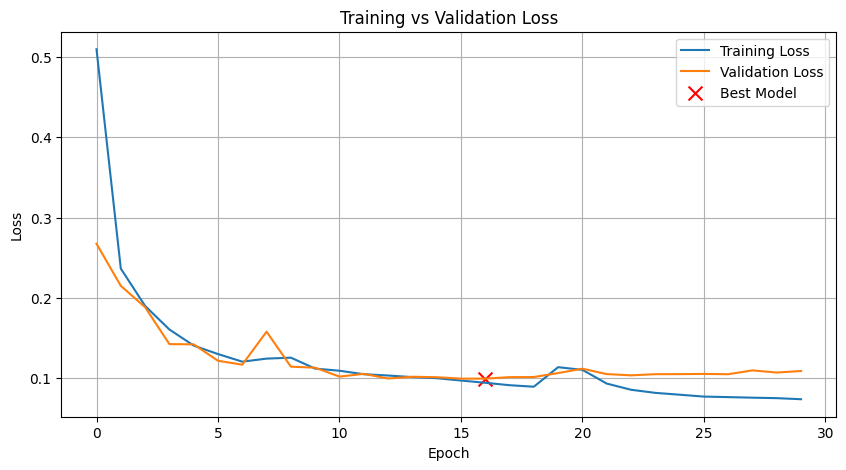

In [17]:
# Plot training and validation loss curves to observe optimisation behaviour.

# Store training and validation history
val_loss = history.history["val_loss"]
train_loss = history.history["loss"]

# Extract the best epoch
best_epoch = np.argmin(val_loss)
best_val = np.min(val_loss)

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.scatter(best_epoch, best_val, color="red", marker="x", s=100, label="Best Model")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


**Training-Validation Dice Coefficient Curve :**

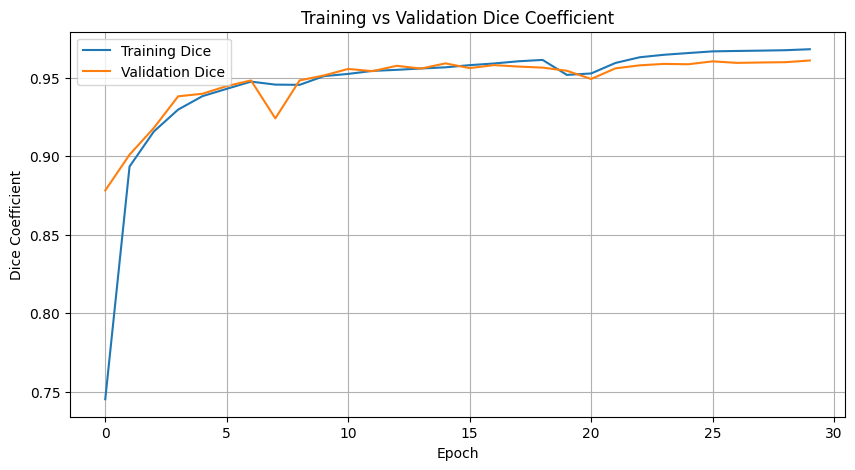

In [18]:
# Plot training and validation Dice coefficient curves.
# Dice is a direct measure of segmentation quality (higher is better).

plt.figure(figsize=(10, 5))
plt.plot(history.history["dice_coefficient"], label="Training Dice")
plt.plot(history.history["val_dice_coefficient"], label="Validation Dice")

plt.title("Training vs Validation Dice Coefficient")
plt.xlabel("Epoch")
plt.ylabel("Dice Coefficient")
plt.legend()
plt.grid(True)
plt.show()


# Model Evaluation and Qualitative Analysis

This section reports the quantitative performance of the trained U‑Net model and provides qualitative examples of its segmentation outputs. Evaluation metrics include loss, Dice coefficient, Intersection over Union (IoU), precision, and recall, calculated on the held‑out test set. Qualitative visualisations compare the input image, ground‑truth mask, and predicted mask to assess segmentation quality and boundary localisation.

**Quantitative Metrics :**

In [19]:
# Evaluate model
test_results = unet.evaluate(X_test, y_test, verbose=1)
print(f"Test Dice Coefficient: {test_results[1]:.4f}")
print(f"Test Loss: {test_results[0]:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 49s 494ms/step - dice_coefficient: 0.9600 - loss: 0.1075
Test Dice Coefficient: 0.9600
Test Loss: 0.1075


In [20]:
# Calculate test-set segmentation metrics (IoU, precision, recall)

preds = unet.predict(X_test)
preds_bin = (preds > 0.5).astype("float32")

iou = jaccard_score(y_test.flatten(), preds_bin.flatten())
precision = precision_score(y_test.flatten(), preds_bin.flatten())
recall = recall_score(y_test.flatten(), preds_bin.flatten())

print("IoU:", iou)
print("Precision:", precision)
print("Recall:", recall)


5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 790ms/step
IoU: 0.9322676426838162
Precision: 0.9566965301299226
Recall: 0.9733404000205732


**Qualitiative Visualisation :**

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


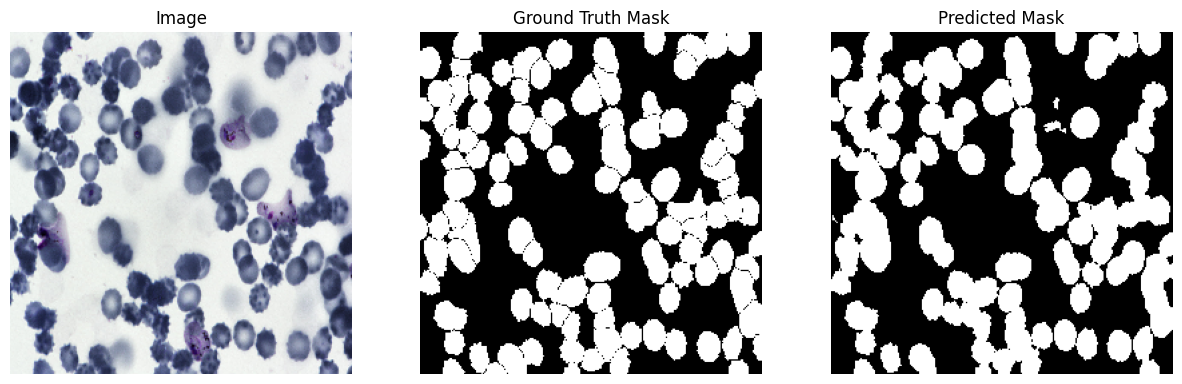

In [21]:
# Pick an index from the test set

i = 27   #change this number to inspect different samples (0 to 132)

# Get the image and ground truth mask
img = X_test[i]
true_mask = y_test[i]

# Predict
pred_mask = unet.predict(img[np.newaxis, ...])[0]
pred_mask = (pred_mask > 0.5).astype("float32")  # threshold

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(true_mask.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.axis("off")

plt.show()


While these metrics evaluate pixel‑wise accuracy, many biomedical applications require instance‑level and morphological analysis. The following section therefore examines how the predicted masks can be used to extract quantitative cell‑level features.

# Post - Segementation Morphological Analysis

Segmentation enables downstream quantitative analysis of cell morphology. Although the U‑Net produces a binary semantic segmentation mask, connected‑component labelling allows the mask to be converted into individual cell instances for analysis. Geometric features such as area, perimeter, eccentricity, and circularity are then extracted for each instance. Population‑level feature distributions are visualised and compared with ground‑truth annotations to assess the morphological fidelity of the model’s predictions.

**Instance Lablelling for a Representative Test Image :**

In [22]:
# Label connected components in the predicted mask (example: first test image)
pred_mask = preds_bin[0, ..., 0]
labeled_pred = label(pred_mask)

# Count number of detected cell instances
num_cells_pred = labeled_pred.max()
num_cells_pred


np.int64(38)

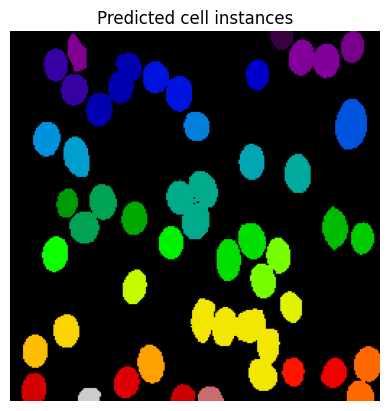

In [23]:
# Visualise labelled instances with a spectral colormap
plt.imshow(labeled_pred, cmap='nipy_spectral')
plt.title("Predicted cell instances")
plt.axis("off")
plt.show()


**Colourmap Caption :**

Each colour corresponds to a distinct connected component (cell instance) identified in the predicted mask.
This visualisation verifies whether the model correctly separates adjacent cells and preserves individual boundaries; a prerequisite for accurate morphological analysis.

**Feature Extraction for the Respresentive Image :**

In [24]:
# Extract morphological features from predicted instances
regions = regionprops(labeled_pred)

features_pred = []
for r in regions:
    features_pred.append({
        "area": r.area,
        "perimeter": r.perimeter,
        "eccentricity": r.eccentricity,
        "circularity": (4 * np.pi * r.area) / (r.perimeter**2 + 1e-8),
    })


features_pred_df = pd.DataFrame(features_pred)
features_pred_df.head()


,area,perimeter,eccentricity,circularity
0,174.0,48.142136,0.556278,0.943427
1,286.0,61.455844,0.685169,0.951589
2,252.0,64.627417,0.883130,0.758188
3,698.0,120.811183,0.778966,0.600968
4,620.0,129.396970,0.911423,0.465322


In [25]:
# Ground-truth instance labelling and feature extraction
gt_mask = y_test[0, ..., 0]
labeled_gt = label(gt_mask)
gt_regions = regionprops(labeled_gt)

features_gt_df = pd.DataFrame([{
    "area": r.area,
    "perimeter": r.perimeter,
    "eccentricity": r.eccentricity,
    "circularity": (4 * np.pi * r.area) / (r.perimeter**2 + 1e-8),
} for r in gt_regions])

features_gt_df.head()

,area,perimeter,eccentricity,circularity
0,167.0,49.349242,0.564750,0.861718
1,273.0,60.284271,0.657566,0.943984
2,236.0,64.284271,0.881550,0.717650
3,660.0,127.396970,0.794862,0.511017
4,589.0,125.396970,0.911553,0.470707


**Summary Statistics**

In [26]:
# Summary statistics for predicted features
summary_pred = features_pred_df.describe().T

# Summary statistics for ground-truth features
summary_gt = features_gt_df.describe().T

# Combine side-by-side for comparison
summary_combined = pd.concat(
    {"Predicted": summary_pred, "Ground Truth": summary_gt},
    axis=1
)

summary_combined

Predicted                                                  \
                 count        mean         std         min         25%   
area              38.0  447.263158  314.612562  124.000000  281.250000   
perimeter         38.0   86.677381   47.327421   41.313708   61.455844   
eccentricity      38.0    0.734142    0.115188    0.494193    0.655626   
circularity       38.0    0.807012    0.207814    0.275773    0.640273   

                                                  Ground Truth              \
                     50%         75%          max        count        mean   
area          332.000000  604.500000  1786.000000         37.0  430.864865   
perimeter      65.991378  113.861436   285.279221         37.0   88.339535   
eccentricity    0.717063    0.806750     0.943271         37.0    0.726929   
circularity     0.916868    0.952392     0.979005         37.0    0.773954   

                                                                          \
                     std         min         25%         50%         75%   
area          232.367664  153.000000  273.000000  329.000000  594.000000   
perimeter      41.544251   46.727922   60.284271   66.526912  125.396970   
eccentricity    0.122094    0.520817    0.635967    0.707804    0.794862   
circularity     0.226879    0.332784    0.511017    0.908437    0.940519   

                           
                      max  
area          1055.000000  
perimeter      187.781746  
eccentricity     0.944418  
circularity      0.981773

Descriptive statistics for geometric features extracted from one representative test image.

**Feature Distribution :**

Area Distribution : Ground Truth vs Predicted

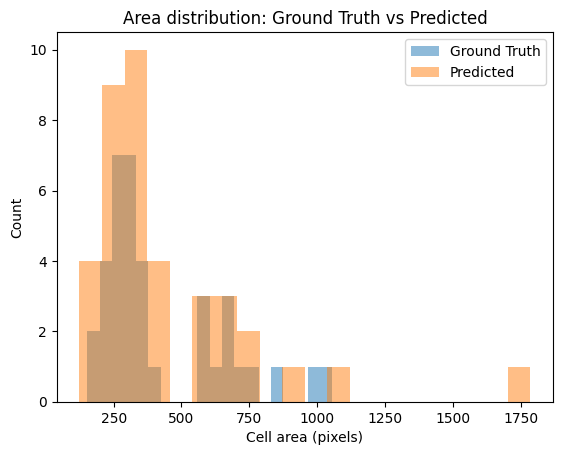

In [27]:
plt.hist(features_gt_df["area"], bins=20, alpha=0.5, label="Ground Truth")
plt.hist(features_pred_df["area"], bins=20, alpha=0.5, label="Predicted")
plt.xlabel("Cell area (pixels)")
plt.ylabel("Count")
plt.title("Area distribution: Ground Truth vs Predicted")
plt.legend()
plt.show()

**Caption :** Histogram comparing the distribution of cell areas between ground‑truth and predicted masks for one test image. Each bar represents the count of detected cell instances within a given area range. This visualisation shows how closely the predicted segmentation reproduces the size variability observed in the ground‑truth annotations

Circular Distribution : Ground Truth vs Predicted

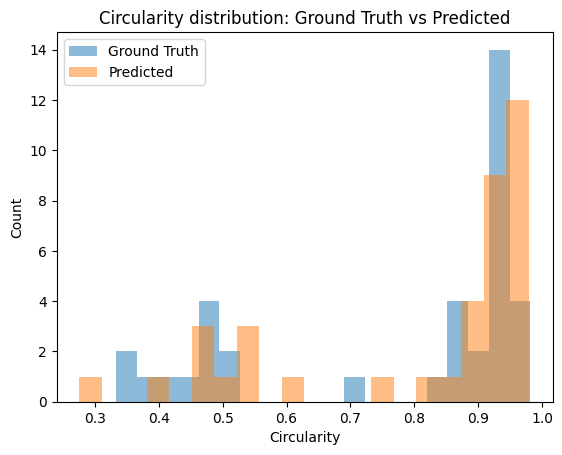

In [28]:
plt.hist(features_gt_df["circularity"], bins=20, alpha=0.5, label="Ground Truth")
plt.hist(features_pred_df["circularity"], bins=20, alpha=0.5, label="Predicted")
plt.xlabel("Circularity")
plt.ylabel("Count")
plt.title("Circularity distribution: Ground Truth vs Predicted")
plt.legend()
plt.show()


**Caption:**
Circularity feature distribution for a representative test image.
Overlap between predicted and ground‑truth histograms indicates morphological consistency, while divergence highlights potential shape or boundary biases.

The representative example illustrates the feature extraction pipeline, but per‑image morphology varies across samples and training runs.
Population‑level conclusions are drawn from the aggregated distributions calculated across the entire test set, which remain stable and reproducible.

**Aggregate Mophological Analysis Across Test Set :**

In [29]:
# Aggregate morphological features across all test images
features_pred_all = []
features_gt_all = []

for i in range(len(y_test)):
    pred_mask = preds_bin[i, ..., 0]
    gt_mask = y_test[i, ..., 0]

    labeled_pred = label(pred_mask)
    labeled_gt = label(gt_mask)

    for r in regionprops(labeled_pred):
        features_pred_all.append({
            "area": r.area,
            "perimeter": r.perimeter,
            "eccentricity": r.eccentricity,
            "circularity": (4 * np.pi * r.area) / (r.perimeter**2 + 1e-8),
        })

    for r in regionprops(labeled_gt):
        features_gt_all.append({
            "area": r.area,
            "perimeter": r.perimeter,
            "eccentricity": r.eccentricity,
            "circularity": (4 * np.pi * r.area) / (r.perimeter**2 + 1e-8),
        })

features_pred_all_df = pd.DataFrame(features_pred_all)
features_gt_all_df = pd.DataFrame(features_gt_all)


**Test set Level Summary Table :**

In [30]:
summary_pred_all = features_pred_all_df.describe().T
summary_gt_all = features_gt_all_df.describe().T

summary_combined_all = pd.concat(
    {"Predicted": summary_pred_all, "Ground Truth": summary_gt_all},
    axis=1
)

summary_combined_all

Predicted                                                    \
                 count          mean           std       min         25%   
area            5442.0  4.652642e+02  8.182837e+02  1.000000  236.000000   
perimeter       5442.0  9.277917e+01  1.270644e+02  0.000000   57.455844   
eccentricity    5442.0  7.092113e-01  1.549199e-01  0.000000    0.634379   
circularity     5442.0  2.493877e+07  2.180733e+08  0.031379    0.719167   

                                                   Ground Truth  \
                     50%         75%           max        count   
area          298.000000  419.750000  2.052100e+04       5361.0   
perimeter      64.284271   82.284271  2.842622e+03       5361.0   
eccentricity    0.712262    0.815975  1.000000e+00       5361.0   
circularity     0.886661    0.935876  2.513274e+09       5361.0   

                                                                             \
                       mean           std       min         25%         50%   
area             464.217870  7.625876e+02  1.000000  236.000000  297.000000   
perimeter        100.390187  1.441319e+02  0.000000   57.698485   64.627417   
eccentricity       0.715834  1.386334e-01  0.000000    0.634862    0.712438   
circularity   234404.234265  1.716275e+07  0.016803    0.570479    0.867717   

                                        
                     75%           max  
area          438.000000  2.332500e+04  
perimeter      98.041631  4.176615e+03  
eccentricity    0.818203  9.847535e-01  
circularity     0.928425  1.256637e+09

Descriptive statistics for geometric features (area, perimeter, eccentricity, circularity) aggregated across all cell instances in the test set. These values summarise population‑level morphology for both predicted and ground‑truth masks.

**Dataset Level Feature Distributions :**

Area Distribution (Ground Truth vs Predicted)

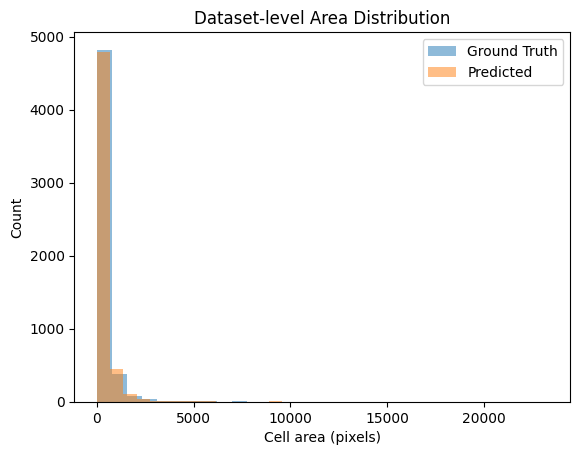

In [31]:
plt.hist(features_gt_all_df["area"], bins=30, alpha=0.5, label="Ground Truth")
plt.hist(features_pred_all_df["area"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Cell area (pixels)")
plt.ylabel("Count")
plt.title("Dataset-level Area Distribution")
plt.legend()
plt.show()

**Caption :** Histogram comparing predicted and ground‑truth cell areas aggregated across the test set.

Circularity Distribution (Ground Truth vs Predicted)

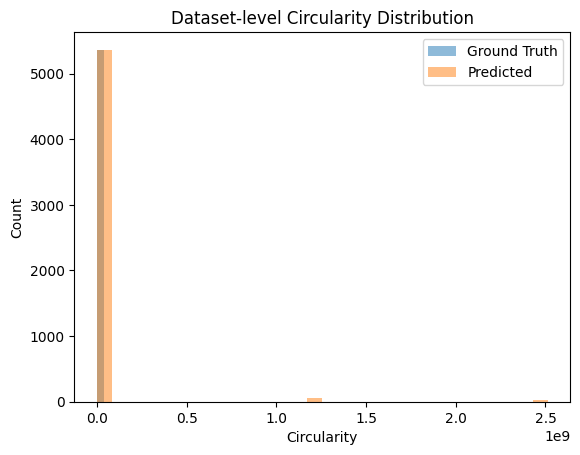

In [32]:
plt.hist(features_gt_all_df["circularity"], bins=30, alpha=0.5, label="Ground Truth")
plt.hist(features_pred_all_df["circularity"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Circularity")
plt.ylabel("Count")
plt.title("Dataset-level Circularity Distribution")
plt.legend()
plt.show()

**Caption :** Histogram comparing predicted and ground‑truth circularity values aggregated across the test set.

**Interpretation of Test Set Level Morphological Fidelity :**

The aggregated feature distributions demonstrate that the model preserves key aspects of cell‑level morphology across the test set. Predicted and ground‑truth area and circularity distributions show strong overlap, indicating that the U‑Net captures population‑level variation in cell size and overall shape. Minor deviations between predicted and ground‑truth perimeter and eccentricity values, observed in the summary statistics, reflect expected boundary‑level differences, as U‑Net predictions tend to produce slightly smoother contours. Overall, the test‑set‑level analysis confirms that the model not only segments cells accurately at the pixel level but also reproduces biologically meaningful geometric properties at the population scale.

# Limitations and Future Work

This section summarises the main limitations of the current approach and outlines potential directions for extending the work. These points contextualise the results and indicate how the model and methodology could be developed further in more realistic or challenging settings. Although the model preserves key morphological distributions, deviations in perimeter highlight the sensitivity of boundary‑dependent shape descriptors to contour smoothness, suggesting potential improvements through instance‑aware architectures or boundary‑refinement losses.

**Limitations :**

* **Single modality:** The model was trained on one imaging modality and one dataset. Performance may not generalise to other microscopy types (e.g., fluorescence, phase‑contrast) without retraining or domain adaptation.

* **Absence of annotation uncertainty:** Ground‑truth masks were treated as perfect, but real annotations often contain inter‑annotator variability that affects model performance.

* **Limited biological variability:** Although augmentations introduce synthetic variability, they do not fully capture the diversity of real microscopy conditions (e.g., staining artefacts, illumination gradients, debris). Broader biological and acquisition variability would be required for real‑world deployment.

**Future Work :**

* **Training on more diverse datasets:** Incorporating additional microscopy datasets would test generalisation and robustness.

* **Instance segmentation:** Extending the model to architectures such as Mask R‑CNN, StarDist, or Cellpose would enable better separation of touching cells.

* **Self‑generated masks:** Creating custom annotations would introduce realistic noise and variability, providing a more rigorous test of robustness beyond IoU improvement.

* **Uncertainty estimation:** Integrating Monte Carlo dropout or test‑time augmentation could quantify prediction confidence and highlight regions of uncertainty.

# Conclusion

This work demonstrates that a U‑Net trained on the BCCD dataset can produce stable semantic segmentations that preserve population‑level morphological properties of the underlying cell distribution. The integration of instance‑level morphological analysis highlights the value of segmentation outputs for downstream quantitative workflows, extending the model’s relevance beyond pixel‑wise accuracy. Taken together, the results establish a solid foundation for future extensions toward more diverse datasets, instance‑aware architectures, and uncertainty‑aware modelling.